# Trabalho Final. Base de Dados: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

In [ ]:
!pip install ucimlrepo

In [ ]:
# Importa a biblioteca pandas, usada para manipulação e análise de dados estruturados (DataFrames e Séries).
import pandas as pd

# Importa a biblioteca NumPy, essencial para computação numérica e manipulação de arrays multidimensionais.
import numpy as np

# Importa as bibliotecas de Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Ignorar warning
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

In [ ]:
from ucimlrepo import fetch_ucirepo

#Consulta da Base
default_of_credit_card_clients = fetch_ucirepo(id=350)

#Separação de features e target
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

In [ ]:
#Unindo features e target
df_features = pd.DataFrame(X)
df_target = pd.DataFrame(y)
df = pd.concat([df_features, df_target], axis=1)

In [ ]:
#Renomeando colunas
cols_features = {
    "X1":  "valor_credito",
    "X2":  "sexo",
    "X3":  "educacao",
    "X4":  "estado_civil",
    "X5":  "idade_anos",
    "X6":  "status_pag_set_2005",
    "X7":  "status_pag_ago_2005",
    "X8":  "status_pag_jul_2005",
    "X9":  "status_pag_jun_2005",
    "X10": "status_pag_mai_2005",
    "X11": "status_pag_abr_2005",
    "X12": "valor_fatura_set_2005",
    "X13": "valor_fatura_ago_2005",
    "X14": "valor_fatura_jul_2005",
    "X15": "valor_fatura_jun_2005",
    "X16": "valor_fatura_mai_2005",
    "X17": "valor_fatura_abr_2005",
    "X18": "valor_pago_set_2005",
    "X19": "valor_pago_ago_2005",
    "X20": "valor_pago_jul_2005",
    "X21": "valor_pago_jun_2005",
    "X22": "valor_pago_mai_2005",
    "X23": "valor_pago_abr_2005"
}
col_target = {
    "Y": "inadimplente"
}

#Aplicação do rename:
df_features.rename(columns=cols_features, inplace=True)
df_target.rename(columns=col_target, inplace=True)

In [ ]:
#Criação de novas features a partir das colunas status_pag_MÊS_ANO

status_pag_cols = [
    'status_pag_set_2005',
    'status_pag_ago_2005',
    'status_pag_jul_2005',
    'status_pag_jun_2005',
    'status_pag_mai_2005',
    'status_pag_abr_2005'
]

#Total de meses com atraso de pagamento (> 0 significa atraso de 1 mês ou mais)
df_features['num_meses_atrasado'] = (df_features[status_pag_cols] > 0).sum(axis=1).astype(int)

#Maior status (quanto maior, maior o atraso, exc. valores de -1 significado “pagamento em dia”)
df_features['maior_atraso'] = df_features[status_pag_cols].max(axis=1)

#Quantidade de pagamentos efetuados pontualmente (-1 = pagamento em dia)
df_features['qtd_pagamentos_em_dia'] = (df_features[status_pag_cols] == -1).sum(axis=1).astype(int)

In [ ]:
#Criação de novas features a partir das colunas valor_fatura_MES_ANO

valor_fatura_cols = [
    "valor_fatura_set_2005",
    "valor_fatura_ago_2005",
    "valor_fatura_jul_2005",
    "valor_fatura_jun_2005",
    "valor_fatura_mai_2005",
    "valor_fatura_abr_2005",
]

#Média mensal da fatura
df_features["fatura_media"] = df_features[valor_fatura_cols].mean(axis=1)

#Soma total das faturas nos 6 meses
df_features["fatura_total"] = df_features[valor_fatura_cols].sum(axis=1)

#Desvio-padrão das faturas (variação)
df_features["variacao_fatura"] = df_features[valor_fatura_cols].std(axis=1)

#Crescimento entre setembro e abril de 2005
df_features["crescimento_fatura"] = df_features["valor_fatura_set_2005"] - df_features["valor_fatura_abr_2005"]

In [ ]:
#Mais duas features a partir das colunas valor_pago_MES_ANO
#Pagamento total do período e saldo total (diferença entre o que foi pago e o que foi faturado)
pagamento_cols = [
    "valor_pago_abr_2005",
    "valor_pago_mai_2005",
    "valor_pago_jun_2005",
    "valor_pago_jul_2005",
    "valor_pago_ago_2005",
    "valor_pago_set_2005",
]

#Pagamento total no período
df_features["pagamento_total"] = df_features[pagamento_cols].sum(axis=1)

#Saldo total
df_features["saldo_total"] = df_features["pagamento_total"] - df_features["fatura_total"]

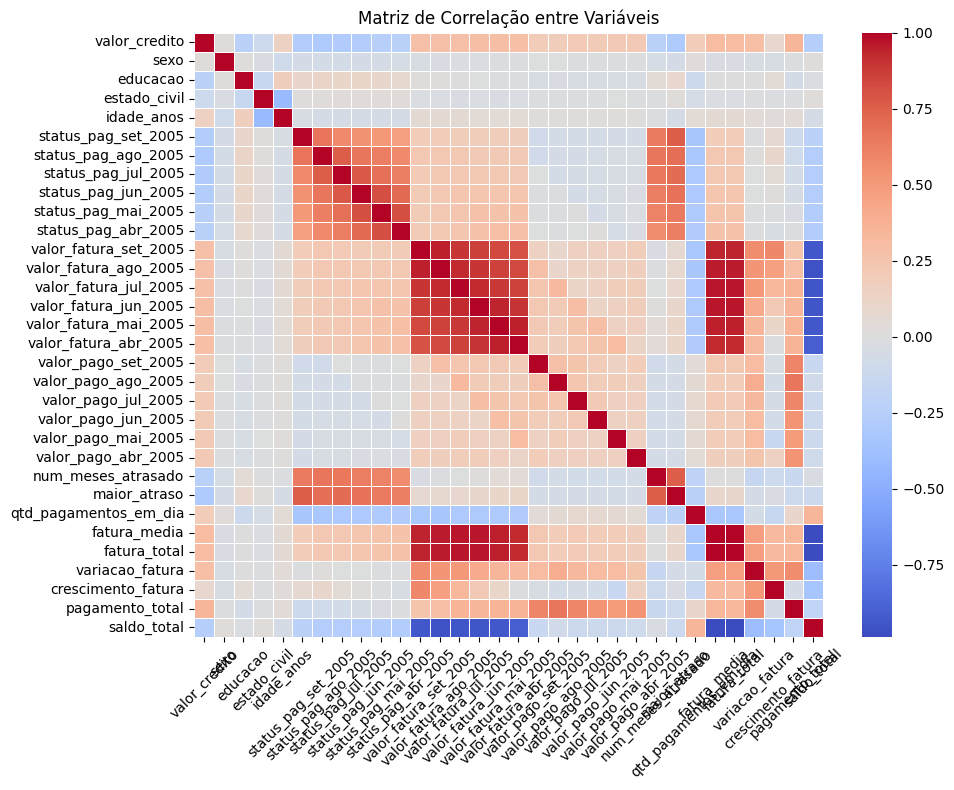

In [ ]:
# Mostrando a matriz de correlação entre as variáveis

# Calcula a matriz de correlação
correlation_matrix = df_features.corr()

# Cria o heatmap com os nomes das variáveis nos eixos
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5,
            xticklabels=correlation_matrix.columns,
            yticklabels=correlation_matrix.columns)
plt.title('Matriz de Correlação entre Variáveis')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Vemos que existe uma vasta gama de colinearidade entre os atributos do tipo "valor_pago" e "status_pag", mostrando que estes não agregarão em nada no modelo, vamos removê-los.

In [ ]:
#Remoção de features (colunas) desnecessárias
cols = [
    "valor_pago_abr_2005",
    "valor_pago_mai_2005",
    "valor_pago_jun_2005",
    "valor_pago_jul_2005",
    "valor_pago_ago_2005",
    "valor_pago_set_2005",
    "status_pag_abr_2005",
    "status_pag_mai_2005",
    "status_pag_jun_2005",
    "status_pag_jul_2005",
    "status_pag_ago_2005",
    "status_pag_set_2005",
    "valor_fatura_set_2005",
    "valor_fatura_ago_2005",
    "valor_fatura_jul_2005",
    "valor_fatura_jun_2005",
    "valor_fatura_mai_2005",
    "valor_fatura_abr_2005"
]

df_features.drop(columns=cols, inplace=True)

## Vamos olhar como ficou a matriz após a deleção

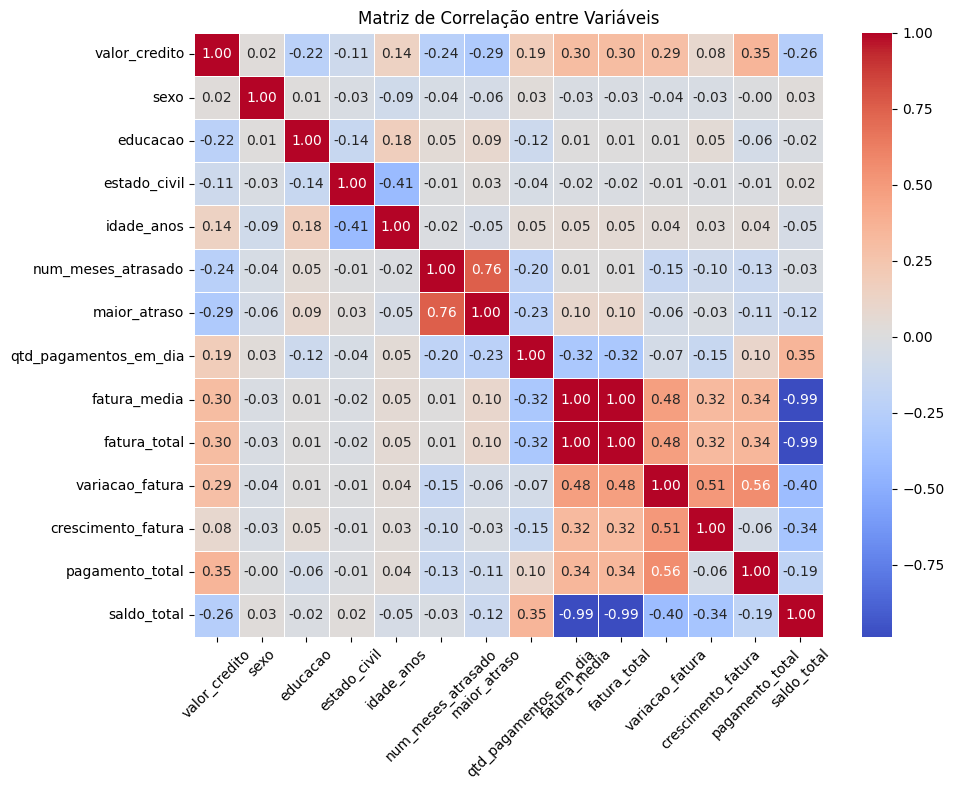

In [ ]:
# Mostrando a matriz de correlação entre as variáveis

# Calcula a matriz de correlação
correlation_matrix = df_features.corr()

# Cria o heatmap com os nomes das variáveis nos eixos
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,
            xticklabels=correlation_matrix.columns,
            yticklabels=correlation_matrix.columns)
plt.title('Matriz de Correlação entre Variáveis')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Melhorou, mas ainda existem fortíssimas colinearidades aqui e ali, como entre $qtd\_pagamentos\_em\_dia$ e $fatura\_total$, que possuem correlação perfeita! Algo claramente está errado, vamos fazer mais algumas análises.

In [ ]:
#Unindo features ao target
df = pd.concat([df_features, df_target], axis=1)

In [ ]:
#Database final
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   valor_credito          30000 non-null  int64  
 1   sexo                   30000 non-null  int64  
 2   educacao               30000 non-null  int64  
 3   estado_civil           30000 non-null  int64  
 4   idade_anos             30000 non-null  int64  
 5   num_meses_atrasado     30000 non-null  int64  
 6   maior_atraso           30000 non-null  int64  
 7   qtd_pagamentos_em_dia  30000 non-null  int64  
 8   fatura_media           30000 non-null  float64
 9   fatura_total           30000 non-null  int64  
 10  variacao_fatura        30000 non-null  float64
 11  crescimento_fatura     30000 non-null  int64  
 12  pagamento_total        30000 non-null  int64  
 13  saldo_total            30000 non-null  int64  
 14  inadimplente           30000 non-null  int64  
dtypes:

In [ ]:
#Removendo números negativos da feature "maior_atraso"
df_features['maior_atraso'] = df_features['maior_atraso'] + 2

df_features['maior_atraso'].unique()

array([ 4,  2,  1,  3,  0,  5,  8,  7,  6, 10,  9])

In [ ]:
#Separação de variaveis qualitatitvas e quantitativas da tabela df_features
cat_df = df_features[['sexo', 'educacao', 'estado_civil']]
num_df = df_features[['maior_atraso', 'valor_credito', 'idade_anos', 'num_meses_atrasado', 'qtd_pagamentos_em_dia', 'fatura_media', 'fatura_total', 'variacao_fatura', 'crescimento_fatura', 'pagamento_total', 'saldo_total']]

In [ ]:
#Verificação das features qualitativas e quantitiativas com o SelectKBest
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import r2_score

#Aplicação do SelectKBest para variáveis:
#Categóricas (Qui-Quadrado)
best_cat = SelectKBest(chi2, k="all")
best_cat.fit(cat_df, df_target)
cat_scores = best_cat.scores_
#Numéricas (R2)
best_num = SelectKBest(r2_score, k="all")
num_scores = list()
for column in num_df.columns:
  best_num.fit(num_df[[column]], df_target)
  num_scores.append(best_num.scores_)

#Criação do dataframe de resultados
cat_df_result = pd.DataFrame(cat_scores, index=cat_df.columns, columns=['Chi-Quadrado'])
num_df_result = pd.DataFrame(num_scores, index=num_df.columns, columns=['R2'])
#Ordenando do maior para o menor
cat_df_result = cat_df_result.sort_values(by='Chi-Quadrado', ascending=False)
num_df_result = num_df_result.sort_values(by='R2', ascending=False)
#Printando resultados
display(cat_df_result, num_df_result)

,Chi-Quadrado
educacao,7.931259
sexo,7.146367
estado_civil,3.120010


,R2
num_meses_atrasado,-0.014084
crescimento_fatura,-0.079081
pagamento_total,-0.270766
qtd_pagamentos_em_dia,-0.316997
variacao_fatura,-0.353910
saldo_total,-0.430257
fatura_media,-0.505501
fatura_total,-0.505505
valor_credito,-1.666337
maior_atraso,-2.608677


### R² é uma métrica que varia de 0 a 1, não possui valores negativos, logo houve algum problema, vamos aplicar uma métrica diferente, a Anova

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

#Aplicação do SelectKBest para variáveis:
#Numéricas (f-score)
best_num = SelectKBest(f_classif, k="all")
num_scores = list()
for column in num_df.columns:
  best_num.fit(num_df[[column]], df_target)
  num_scores.append(best_num.scores_)

#Criação do dataframe de resultados
num_df_result = pd.DataFrame(num_scores, index=num_df.columns, columns=['F_Score'])
#Ordenando do maior para o menor
num_df_result = num_df_result.sort_values(by='F_Score', ascending=False)
#Printando resultados
display(num_df_result)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

,F_Score
num_meses_atrasado,5659.487447
maior_atraso,3691.914796
valor_credito,724.068539
pagamento_total,317.598973
qtd_pagamentos_em_dia,218.022242
variacao_fatura,192.457893
crescimento_fatura,19.748084
idade_anos,5.788556
fatura_media,4.832575
fatura_total,4.832575


### Após análise das variáveis verificamos que as mais importantes, entre as quantitativas foram:
- num_meses_atrasado
- maior_atraso
- valor_credito
- pagamento_total
- qtd_pagamentos_em_dia
- variacao_fatura,

### as demais serão excluídas.

### Quanto às qualitativas serão todas mantidas, assim temos:

In [ ]:
df_features = df_features.drop(columns=['crescimento_fatura', 'idade_anos', 'fatura_media', 'fatura_total', 'saldo_total'])

#Unindo features ao target
df = pd.concat([df_features, df_target], axis=1)

#### Vamos checar como ficou a matriz após feito estas mudanças

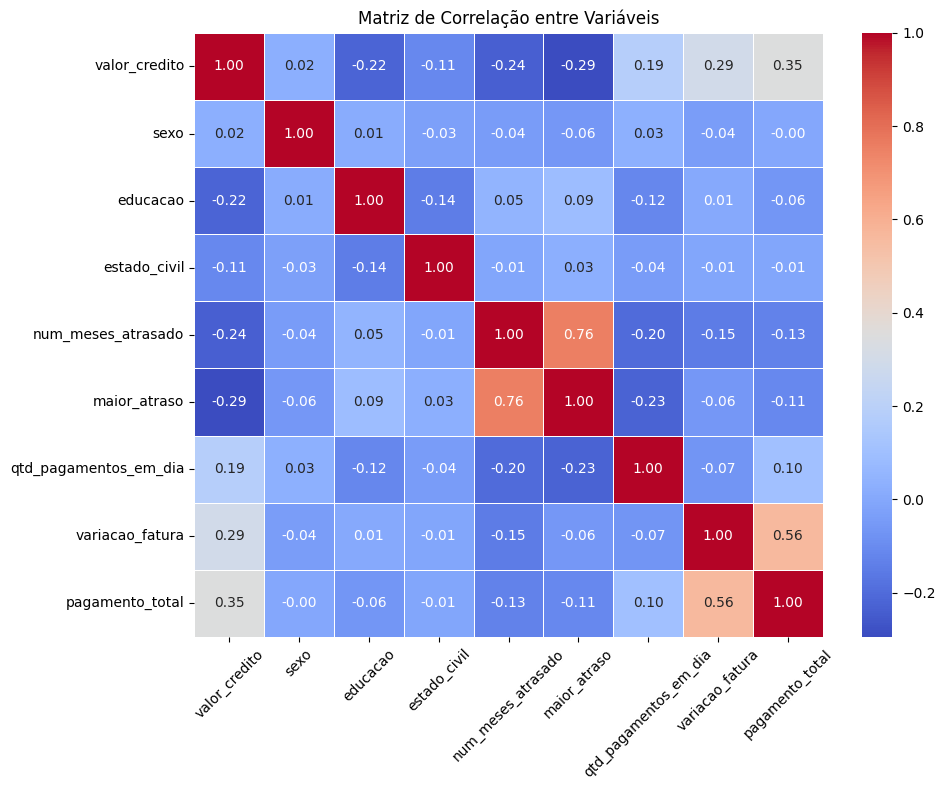

In [ ]:
# Mostrando a matriz de correlação entre as variáveis

# Calcula a matriz de correlação
correlation_matrix = df_features.corr()

# Cria o heatmap com os nomes das variáveis nos eixos
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,
            xticklabels=correlation_matrix.columns,
            yticklabels=correlation_matrix.columns)
plt.title('Matriz de Correlação entre Variáveis')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Ótimo! Chegamos à melhor situação, por mais que ainda existam algumas nuâncias, não são pesadas, podemos trabalhar com isso.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   valor_credito          30000 non-null  int64  
 1   sexo                   30000 non-null  int64  
 2   educacao               30000 non-null  int64  
 3   estado_civil           30000 non-null  int64  
 4   num_meses_atrasado     30000 non-null  int64  
 5   maior_atraso           30000 non-null  int64  
 6   qtd_pagamentos_em_dia  30000 non-null  int64  
 7   variacao_fatura        30000 non-null  float64
 8   pagamento_total        30000 non-null  int64  
 9   inadimplente           30000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 2.3 MB


In [ ]:
# Verificandno balanceamento do target
print(np.bincount(df_target['inadimplente'].tolist()))

# DESBALANCEADO, usar SMOTE?

[23364  6636]


In [ ]:
############# APLICAÇÃO DO ALGORITMO DE ML (Classificação) #############

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Separação features e target
X = df.drop("inadimplente", axis=1)
y = df["inadimplente"]

#Treino e teste (separação)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar modelo de classificação
# model = RandomForestClassifier(random_state=42)
# model = LogisticRegression(random_state=42)
# model = KNeighborsClassifier(n_neighbors=5)
# model = SVC(kernel='rbf', random_state=42)
# model = DecisionTreeClassifier(random_state=42)
model = GradientBoostingClassifier(random_state=42)
# model = GaussianNB()
# model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
# model = SGDClassifier(random_state=42)


model.fit(X_train, y_train)

# Avaliação
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Acurácia
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia no treino: {acc_train:.4f}")
print(f"Acurácia no teste: {acc_test:.4f}\n")

# Relatório de classificação (somente para o teste)
print("Relatório de classificação (teste):")
print(classification_report(y_test, y_pred_test))

Acurácia no treino: 0.8094
Acurácia no teste: 0.8060

Relatório de classificação (teste):
              precision    recall  f1-score   support

           0       0.83      0.95      0.88      4687
           1       0.62      0.30      0.40      1313

    accuracy                           0.81      6000
   macro avg       0.72      0.62      0.64      6000
weighted avg       0.78      0.81      0.78      6000



In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_test)
print(f"Acurácia Teste: {accuracy:.2%}")

Acurácia Teste: 80.60%


              precision    recall  f1-score   support

           0       0.83      0.95      0.88      4687
           1       0.62      0.30      0.40      1313

    accuracy                           0.81      6000
   macro avg       0.72      0.62      0.64      6000
weighted avg       0.78      0.81      0.78      6000

Matriz de Confusão:
 [[4446  241]
 [ 923  390]]


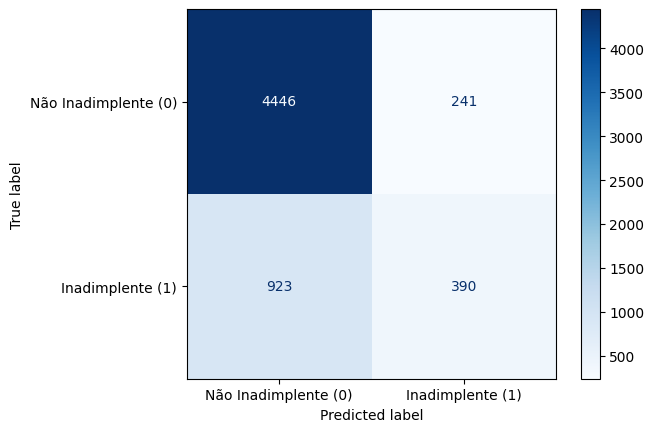

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Relatório completo
print(classification_report(y_test, y_pred_test))

#Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_test)
print("Matriz de Confusão:\n", cm)

#Gráfico da Matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Não Inadimplente (0)", "Inadimplente (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
'''# Obtendo os escores para precisão e revocação no conjunto de teste
precisionscore = precision_score(y_test, y_pred_test)
recallscore = recall_score(y_test, y_pred_test)
display(precisionscore, recallscore)'''

'# Obtendo os escores para precisão e revocação no conjunto de teste\nprecisionscore = precision_score(y_test, y_pred_test)\nrecallscore = recall_score(y_test, y_pred_test)\ndisplay(precisionscore, recallscore)'

In [ ]:
# Obtendo os escores para precisão e revocação no conjunto de treino
precisionscore = precision_score(y_train, y_pred_train)
recallscore = recall_score(y_train, y_pred_train)
display(precisionscore, recallscore)

0.6424219345011424

0.31692654518128877

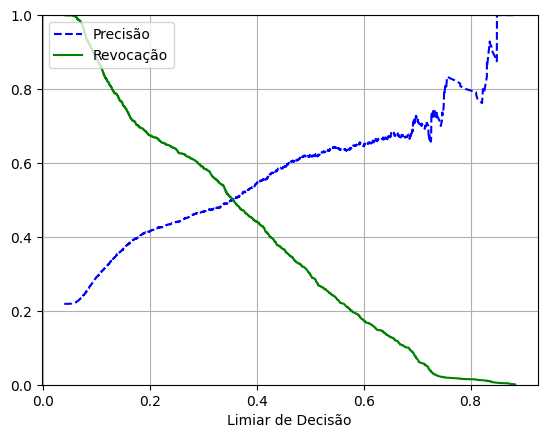

In [ ]:
# Curva Precision-Recall com o conjunto de teste
# Obtendo os escores do modelo
y_scores_test = model.predict_proba(X_test)[:, 1] # -> Outros modelos
# y_scores = model.decision_function(X_test) # -> SGDClassifier and SVC

# Plotando a curva Precision-Recall
precisions_test, recalls_test, thresholds = precision_recall_curve(y_test, y_scores_test)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precisão")
    plt.plot(thresholds, recalls[:-1], "g-", label="Revocação")
    plt.grid(True)
    plt.xlabel("Limiar de Decisão")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])
    plt.show()

plot_precision_recall_vs_threshold(precisions_test, recalls_test, thresholds)

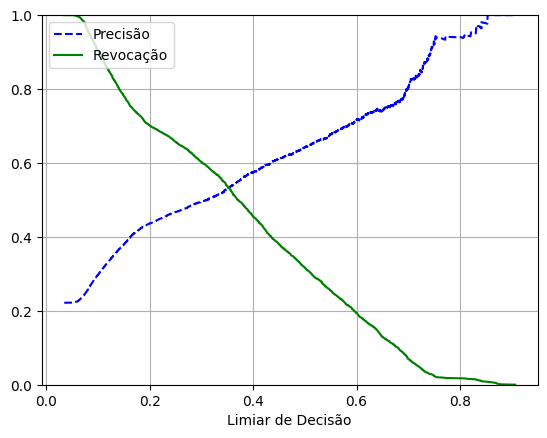

In [ ]:
# Curva Precision-Recall com o conjunto de treino

# Obtendo os escores do modelo
y_scores_train = model.predict_proba(X_train)[:, 1] # -> Outros modelos
# y_scores = model.decision_function(X_train) # -> SGDClassifier and SVC

# Plotando a curva Precision-Recall
precisions_train, recalls_train, thresholds = precision_recall_curve(y_train, y_scores_train)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precisão")
    plt.plot(thresholds, recalls[:-1], "g-", label="Revocação")
    plt.grid(True)
    plt.xlabel("Limiar de Decisão")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])
    plt.show()

plot_precision_recall_vs_threshold(precisions_train, recalls_train, thresholds)

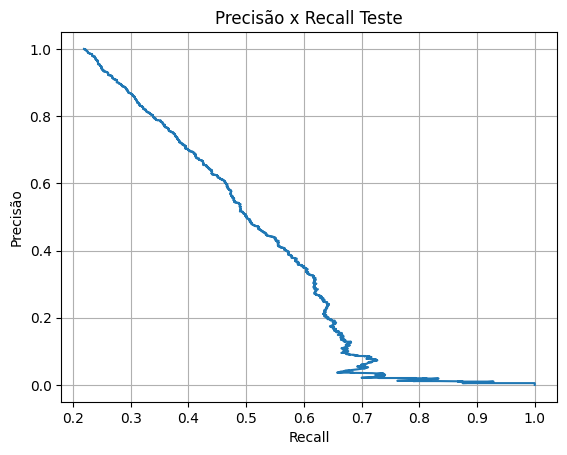

In [ ]:
# Plotando o gráfico Precisão x Recall
plt.plot(precisions_test, recalls_test)
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Precisão x Recall Teste')
plt.grid(True)
plt.show()

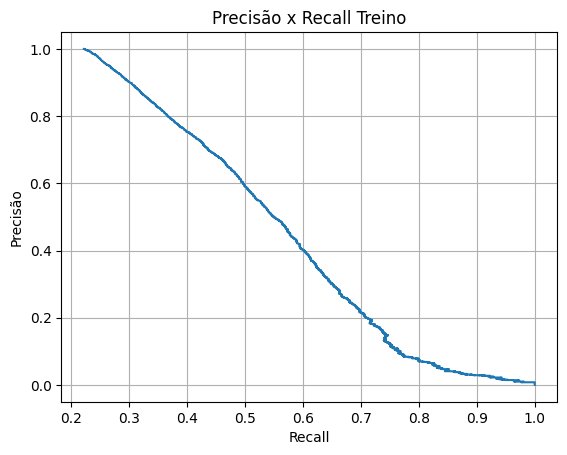

In [ ]:
# Plotando o gráfico Precisão x Recall
plt.plot(precisions_train, recalls_train)
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Precisão x Recall Treino')
plt.grid(True)
plt.show()

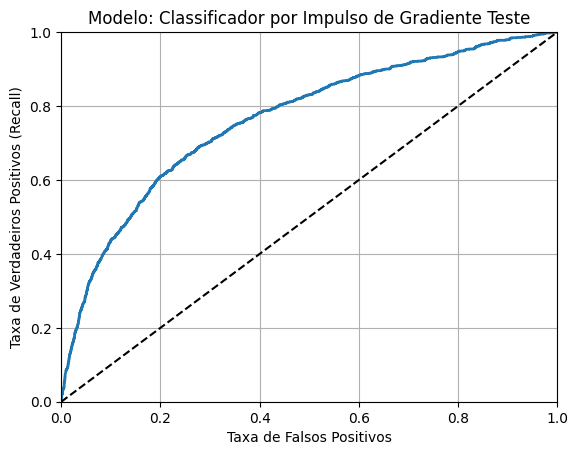

In [ ]:
# Curva ROC com o conjunto de teste

# Plotando a curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores_test)

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
    plt.title('Modelo: Classificador por Impulso de Gradiente Teste')
    plt.grid(True)
    plt.axis([0, 1, 0, 1])
    plt.show()

plot_roc_curve(fpr, tpr)

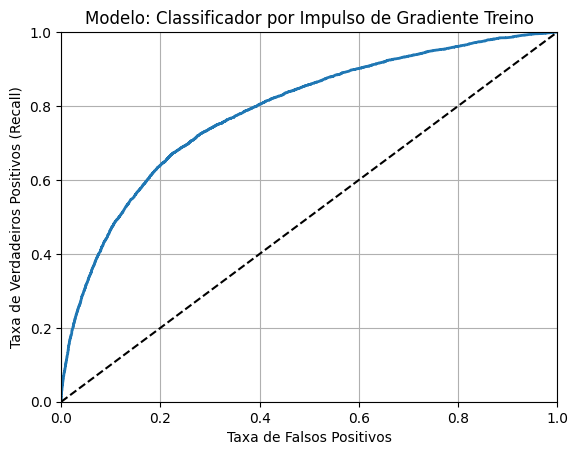

In [ ]:
# Curva ROC com o conjunto de treino

# Plotando a curva ROC
fpr, tpr, thresholds = roc_curve(y_train, y_scores_train)

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
    plt.title('Modelo: Classificador por Impulso de Gradiente Treino')
    plt.grid(True)
    plt.axis([0, 1, 0, 1])
    plt.show()

plot_roc_curve(fpr, tpr)

In [ ]:
# Escore do treino

# Vendo o escore
roc_auc_score(y_train, y_scores_train)

np.float64(0.7871453556782676)

In [ ]:
# Escore do teste

# Vendo o escore
roc_auc_score(y_test, y_scores_test)

np.float64(0.7639428530665511)

In [ ]:
#Teste do modelo com exemplo imputado pelo usuário, para verificação de encaixe no perfil de inadimplente:
#sexo: 2 (feminino)
#educacao: 2 (universitário)
#estado_civil: 2 (solteiro)
#num_meses_atrasado: 3
#maior_atraso: 4 (maior número de meses em atraso)
#qtd_pagamentos_em_dia: 5
#variacao_fatura: 150.5
#pagamento_total: 4000
#valor_credito: 20000

#Exemplo de cliente com características específicas
cliente_exemplo = [[2, 2, 2, 3, 4, 5, 150.5, 4000, 20000]]

#Previsão se inadimplente
previsao = model.predict(cliente_exemplo)
if previsao[0] == 0:
  print("Cliente se encaixa no perfil de NÃO INADIMPLENTE.\n\n")
else:
  print("Cliente se encaixa no perfil de INADIMPLENTE.\n\n")

Cliente se encaixa no perfil de INADIMPLENTE.




/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#Exemplo de cliente com características específicas
cliente_exemplo = [[2, 2, 2, 0, 1, 5, 150.5, 4000, 20000]]

#Previsão se inadimplente
previsao = model.predict(cliente_exemplo)
if previsao[0] == 0:
  print("Cliente se encaixa no perfil de NÃO INADIMPLENTE.\n\n")
else:
  print("Cliente se encaixa no perfil de INADIMPLENTE.\n\n")

Cliente se encaixa no perfil de NÃO INADIMPLENTE.




/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
